In [ ]:
TRAIN_PATH = "train_preprocessed_100k.parquet"
VAL_PATH   = "val_preprocessed_100k.parquet"

train = pl.read_parquet(TRAIN_PATH)
val   = pl.read_parquet(VAL_PATH)

print(train.shape, val.shape)

NameError: name 'pl' is not defined

In [ ]:
import polars as pl
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [ ]:
TRAIN_PATH = "train_preprocessed_100k.parquet"
VAL_PATH   = "val_preprocessed_100k.parquet"

train = pl.read_parquet(TRAIN_PATH)
val   = pl.read_parquet(VAL_PATH)

print(train.shape, val.shape)

(100000, 35) (100000, 35)


In [ ]:
SENTINEL_RECENCY = 999.0

def _days_since_shown(row) -> float:
    tmpl = row["selected_template"]
    hist = row["history"]
    if hist is None or len(hist) == 0:
        return SENTINEL_RECENCY
    matching = [float(h["n_days"]) for h in hist if h.get("template") == tmpl]
    return float(min(matching)) if matching else SENTINEL_RECENCY

def add_recency(df: pl.DataFrame, out_col: str = "recency") -> pl.DataFrame:
    return df.with_columns(
        pl.struct(["selected_template", "history"])
          .map_elements(_days_since_shown, return_dtype=pl.Float64)
          .alias(out_col)
    )

In [ ]:
needed = [
    "session_end_completed",
    "selected_template",
    "eligible_templates",
    "history", # required for recency
    "n_eligible",
    "history_length",
    "hour_utc",
    "day_index",
    "time_since_last_notification_days",
    "max_template_count_last_5",
]
print([c for c in needed if c not in train.columns])

['time_since_last_notification_days']


In [ ]:
print("train baseline:", train.select(pl.mean("session_end_completed")).item())
print("val baseline:  ", val.select(pl.mean("session_end_completed")).item())

train baseline: 0.14704
val baseline:   0.13557


In [ ]:
train = add_recency(train, out_col="recency")
val   = add_recency(val,   out_col="recency")

# now you may drop history safely (logged tables)
train = train.drop(["history"])
val   = val.drop(["history"])

In [ ]:
train.head(10)

datetime,ui_language_ar,ui_language_cs,ui_language_de,ui_language_dn,ui_language_el,ui_language_en,ui_language_es,ui_language_fr,ui_language_hi,ui_language_hu,ui_language_id,ui_language_it,ui_language_ja,ui_language_ko,ui_language_pl,ui_language_pt,ui_language_ro,ui_language_ru,ui_language_th,ui_language_tr,ui_language_uk,ui_language_vi,ui_language_zs,selected_template,eligible_templates,history_length,n_eligible,time_of_day,session_end_completed,hour_utc,days_since_last_notification,max_template_count_last_5,day_index,recency
f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,list[str],u32,u32,f64,bool,i8,f64,i16,i32,f64
9.28338,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""L""","[""K"", ""H"", … ""D""]",3,9,9.28338,false,6,0.999994,1,10,0.999994
9.623044,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""D""","[""K"", ""H"", … ""D""]",11,9,9.623044,false,14,0.999996,1,10,7.003567
5.172986,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""K""","[""G"", ""E"", … ""D""]",3,10,5.172986,false,4,1.693507,2,6,999.0
6.269595,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""G""","[""G"", ""E"", … ""D""]",7,9,6.269595,false,6,1.001365,1,7,1.001365
0.913009,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""L""","[""G"", ""E"", … ""D""]",1,9,0.913009,false,21,0.999999,1,1,0.999999
0.636458,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""D""","[""G"", ""E"", … ""D""]",14,10,0.636458,false,15,1.010333,1,1,1.010333
9.939329,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""F""","[""K"", ""H"", … ""A""]",6,10,9.939329,false,22,1.026598,1,10,5.041424
5.212697,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""E""","[""G"", ""E"", … ""D""]",5,9,5.212697,false,5,0.999998,2,6,0.999998
5.104537,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""A""","[""G"", ""E"", … ""D""]",34,10,5.104537,false,2,0.438472,2,6,7.996732


In [ ]:
# One-hot encode selected_template in TRAIN
train_m = train.to_dummies(columns=["selected_template"])

val_m = val.to_dummies(columns=["selected_template"])

In [ ]:
# ---- IMPORTANT: align val_m columns to train_m ----
missing_cols = [c for c in train_m.columns if c not in val_m.columns]
for c in missing_cols:
    val_m = val_m.with_columns(pl.lit(0).cast(pl.UInt8).alias(c))

# Drop any extra columns in val_m that are not in train_m (rare but safe)
val_m = val_m.select(train_m.columns)

assert train_m.columns == val_m.columns

In [ ]:
drop_cols = [
    "session_end_completed",  # label
    "eligible_templates",     # list column
]

X_train = train_m.drop(drop_cols).to_pandas()
y_train = train_m["session_end_completed"].to_pandas().astype(int)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
print("RF trained.")

RF trained.


In [ ]:
X_val_logged = val_m.drop(drop_cols).to_pandas()
y_val = val_m["session_end_completed"].to_pandas().astype(int)

pred_val = rf.predict_proba(X_val_logged)[:, 1]
print("Logged AUC:", roc_auc_score(y_val, pred_val))

Logged AUC: 0.8093797977619144


In [ ]:
val_id = val.with_row_index("row_id")

cand = (
    val_id
    .explode("eligible_templates")
    .rename({"eligible_templates": "candidate_template"})
    .with_columns(pl.col("candidate_template").alias("selected_template"))
)

In [ ]:
# one-hot encode candidate template
cand_m = cand.to_dummies(columns=["selected_template"])

# align candidate columns to train_m
missing_cols = [c for c in train_m.columns if c not in cand_m.columns]
for c in missing_cols:
    cand_m = cand_m.with_columns(pl.lit(0).cast(pl.UInt8).alias(c))

cand_m = cand_m.select(train_m.columns)

In [ ]:
# predict for each candidate
X_cand = cand_m.drop(drop_cols).to_pandas()
cand = cand.with_columns(pl.Series("pred", rf.predict_proba(X_cand)[:, 1]))

In [ ]:
# choose best per row
chosen = (
    cand.sort(["row_id", "pred"], descending=[False, True])
        .group_by("row_id")
        .agg([
            pl.first("candidate_template").alias("model_choice"),
            pl.first("pred").alias("model_pred"),
        ])
)

In [ ]:
#  evaluate with IPS
val_eval = (
    val_id.join(chosen, on="row_id", how="left")
          .with_columns([
              (pl.col("model_choice") == pl.col("selected_template")).alias("match"),
              pl.col("eligible_templates").list.len().alias("pool_size"),
          ])
)

ips = val_eval.select(
    (pl.col("match").cast(pl.Float64)
     * pl.col("session_end_completed").cast(pl.Float64)
     * pl.col("pool_size").cast(pl.Float64)
    ).mean()
).item()

baseline = val_eval.select(pl.mean("session_end_completed")).item()

print("VAL baseline reward:", baseline)
print("VAL IPS reward (RF greedy):", ips)
print("Relative lift:", (ips - baseline) / baseline)

VAL baseline reward: 0.13557
VAL IPS reward (RF greedy): 0.13734
Relative lift: 0.013055985837574639


In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(15))

n_eligible                      0.315322
days_since_last_notification    0.260579
history_length                  0.139749
selected_template_C             0.055508
recency                         0.045993
hour_utc                        0.033625
max_template_count_last_5       0.033441
time_of_day                     0.029729
datetime                        0.029467
day_index                       0.011415
selected_template_A             0.008737
ui_language_en                  0.006867
ui_language_es                  0.005915
ui_language_ja                  0.004708
ui_language_pt                  0.001994
dtype: float64


In [ ]:
template_importance = importances[
    importances.index.str.startswith("selected_template_")
].sum()

print("Total template importance:", template_importance)

Total template importance: 0.07613952481504398


In [ ]:
PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    ["time_since_last_notification_days"]
)
plt.show()

ValueError: Feature 'time_since_last_notification_days' not in feature_names

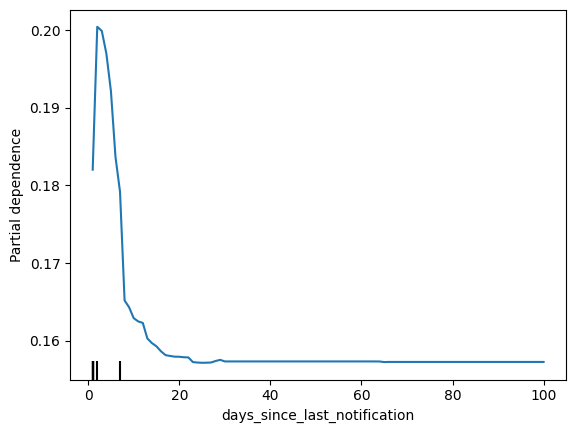

In [ ]:
PartialDependenceDisplay.from_estimator(
    rf,
    X_train,
    ["days_since_last_notification"]
)
plt.show()